In [2]:
import matplotlib
import pandas

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("series-090326.csv", encoding="latin1")

In [6]:
df.columns = ["date", "days_lost"]

In [7]:
df = df[df["date"].str.match(r"\d{4}", na=False)]

In [8]:
print(df.head())
print(df.columns)

    date days_lost
7   1891      6809
8   1892      7382
9   1893     30439
10  1894      9506
11  1895      5701
Index(['date', 'days_lost'], dtype='str')


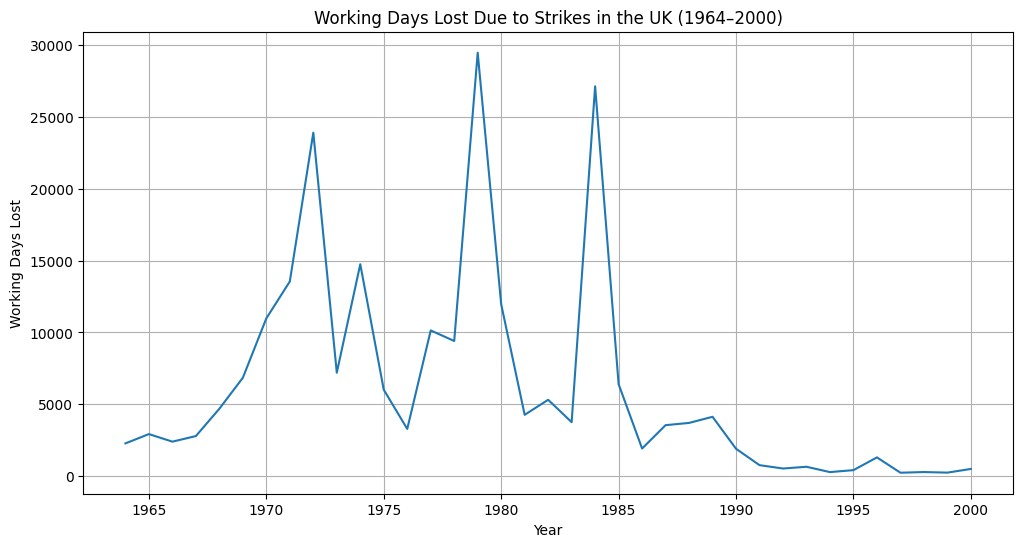

In [9]:
df["days_lost"] = pd.to_numeric(df["days_lost"], errors="coerce")

df["date"] = pd.to_datetime(df["date"], errors="coerce")

# removing invalid rows
df = df.dropna()

# filtering period
df = df[(df["date"].dt.year >= 1964) & (df["date"].dt.year <= 2000)]

# converting monthly values into yearly totals
df_yearly = df.groupby(df["date"].dt.year)["days_lost"].sum()

# plot
plt.figure(figsize=(12,6))
plt.plot(df_yearly.index, df_yearly.values)

plt.title("Working Days Lost Due to Strikes in the UK (1964–2000)")
plt.xlabel("Year")
plt.ylabel("Working Days Lost")
plt.grid(True)

plt.show()

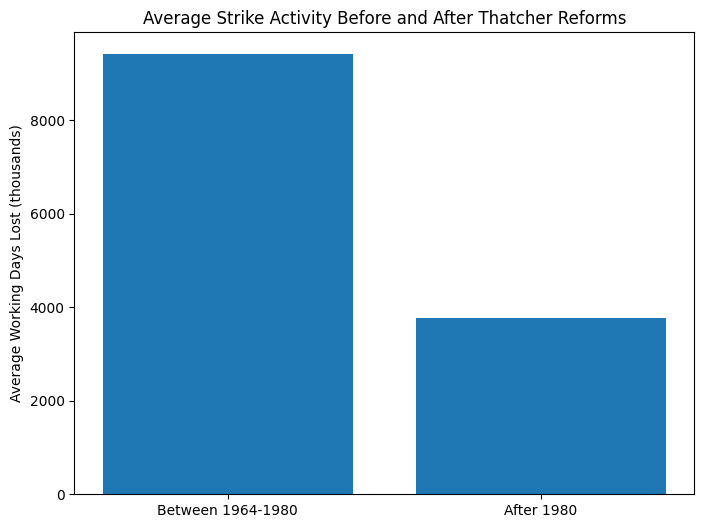

In [10]:
before_thatcher = df_yearly[df_yearly.index < 1980].mean()
after_thatcher = df_yearly[df_yearly.index >= 1980].mean()

plt.figure(figsize=(8,6))
plt.bar(["Between 1964-1980", "After 1980"], [before_thatcher, after_thatcher])

plt.title("Average Strike Activity Before and After Thatcher Reforms")
plt.ylabel("Average Working Days Lost (thousands)")

plt.show()

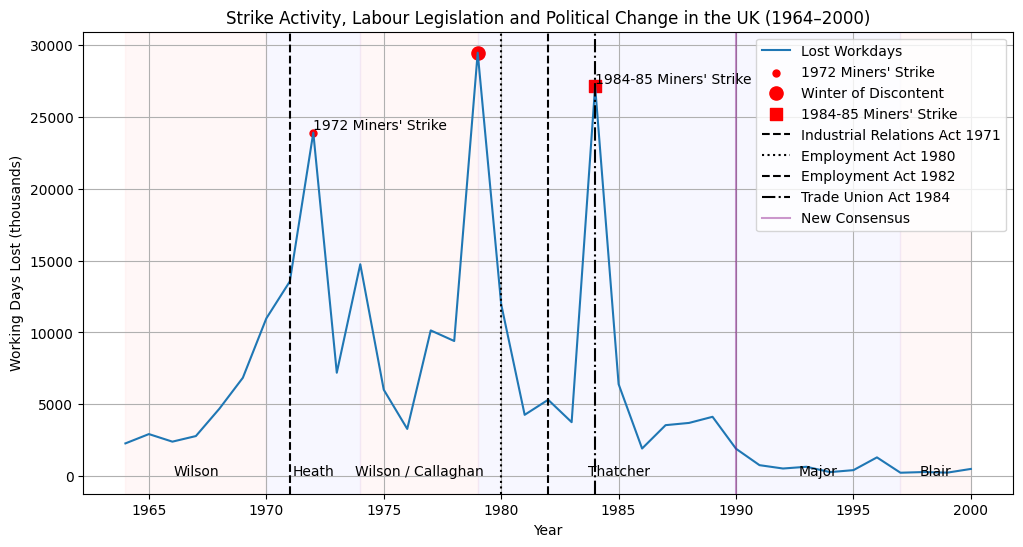

In [31]:
plt.figure(figsize=(12,6))

# main line
plt.plot(df_yearly.index, df_yearly.values, label="Lost Workdays")

# major strikes
plt.scatter(1972, df_yearly.loc[1972], s=100, marker=".", color="red", label="1972 Miners' Strike")
plt.text(1972, df_yearly.loc[1972], "1972 Miners' Strike", verticalalignment="bottom")

plt.scatter(1979, df_yearly.loc[1979], s=90, marker="o", color="red", label="Winter of Discontent")

plt.scatter(1984, df_yearly.loc[1984], s=80, marker="s", color="red", label="1984-85 Miners' Strike")
plt.text(1984, df_yearly.loc[1984], "1984-85 Miners' Strike", verticalalignment="bottom")


# anti-union legislation
plt.axvline(x=1971, linestyle="--", color="black", label="Industrial Relations Act 1971")
plt.axvline(x=1980, linestyle=":", color="black", label="Employment Act 1980")
plt.axvline(x=1982, linestyle="--", color="black", label="Employment Act 1982")
plt.axvline(x=1984, linestyle="-.", color="black", label="Trade Union Act 1984")


# PM periods
y_bottom = df_yearly.min() * 0.1
plt.axvspan(1964, 1970, alpha=0.03, color="red")
plt.text(1967, y_bottom, "Wilson", ha="center")

plt.axvspan(1970, 1974, alpha=0.03, color="blue")
plt.text(1972, y_bottom, "Heath", ha="center")

plt.axvspan(1974, 1979, alpha=0.03, color="red")
plt.text(1976.5, y_bottom, "Wilson / Callaghan", ha="center")

plt.axvspan(1979, 1990, alpha=0.03, color="blue")
plt.text(1985, y_bottom, "Thatcher", ha="center")

plt.axvline(x=1990, linestyle="-", alpha=0.40, color="purple", label="New Consensus")

plt.axvspan(1990, 1997, alpha=0.03, color="blue")
plt.text(1993.5, y_bottom, "Major", ha="center")

plt.axvspan(1997, 2000, alpha=0.03, color="red")
plt.text(1998.5, y_bottom, "Blair", ha="center")

# labels
plt.title("Strike Activity, Labour Legislation and Political Change in the UK (1964–2000)")
plt.xlabel("Year")
plt.ylabel("Working Days Lost (thousands)")

plt.legend()
plt.grid(True)

plt.show()